In [17]:
from tensorflow import keras
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
import random

from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, precision_recall_curve

from config import N_MELS, SAMPLING_RATE, N_FFT, HOP_LENGTH, SEED
from utils import load_image_dataset, show_confusion_matrix, show_importances_heatmap, show_precision_recall_curve

In [18]:
random.seed(SEED)

# Evaluación de modelos

Elegimos el dataset a evaluar

In [19]:
dataset = 'ciclos/mic'

## Random Forest 

### Espectrogramas Mel

In [20]:
test_data = np.load(f'./data_procesada/{dataset}/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [21]:
melspec_rf = joblib.load(f'./modelos_clasicos/modelos/{dataset}/melspec_rf.pkl')

In [22]:
melspec_rf.max_features, melspec_rf.n_estimators, melspec_rf.max_depth, melspec_rf.min_samples_split, melspec_rf.min_samples_leaf

('sqrt', 100, 14, 26, 12)

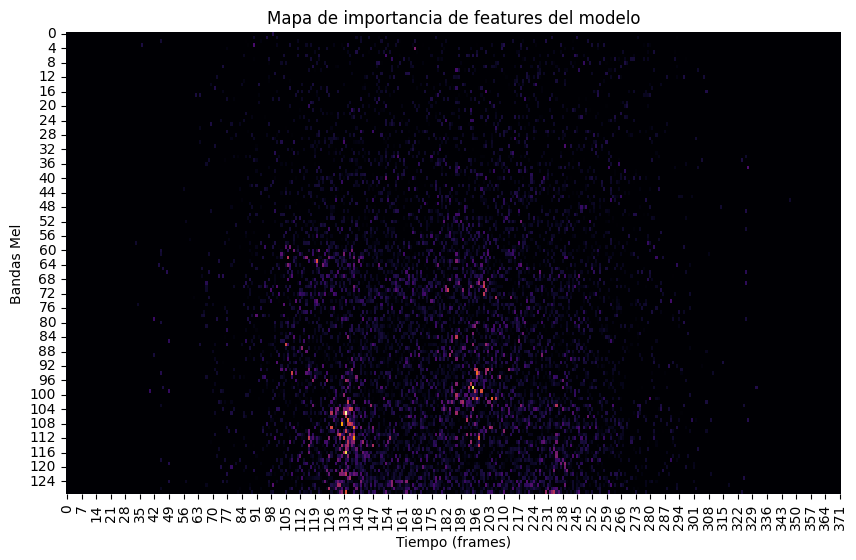

In [23]:
importances = melspec_rf.feature_importances_

show_importances_heatmap(importances);

Hacemos predicciones con el conjunto de testeo

In [24]:
y_pred = melspec_rf.predict(X_test)
y_pred_proba = melspec_rf.predict_proba(X_test)[:, 1]

Vemos:
1. La distribución de las probabilidades predichas, lo ideal sería ver una forma de "U".
2. La curva ROC
3. La curva de precisión recall que nos puede ayudar a encontrar un buen umbral de decisión.
4. Y la matriz de confusión

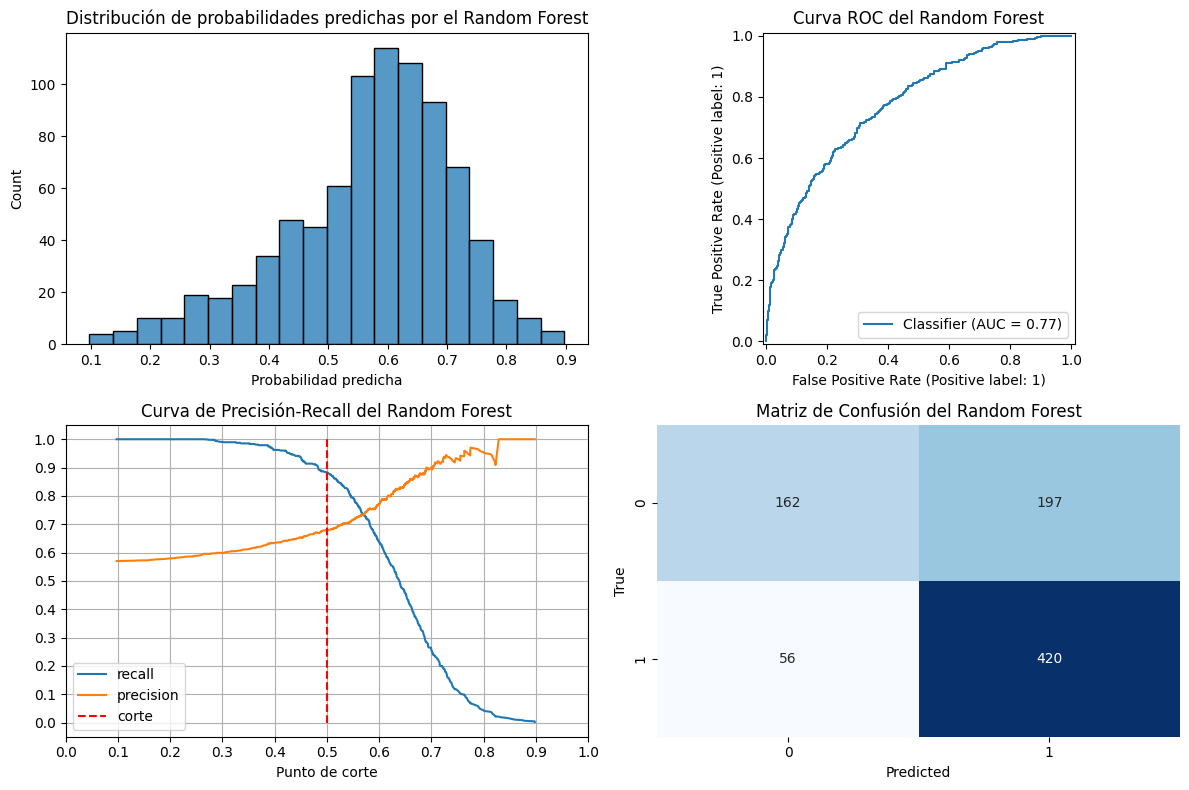

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(y_pred_proba, bins=20, ax=axes[0,0])
axes[0,0].set_title('Distribución de probabilidades predichas por el Random Forest')
axes[0,0].set_xlabel('Probabilidad predicha')

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0,1])
axes[0,1].set_title('Curva ROC del Random Forest')

show_precision_recall_curve(y_test, y_pred_proba, ax=axes[1,0])
axes[1,0].set_title('Curva de Precisión-Recall del Random Forest')

show_confusion_matrix(y_test, y_pred, ax=axes[1,1])
axes[1,1].set_title('Matriz de Confusión del Random Forest')

plt.tight_layout()

Observamos distintas métricas de clasificación adicionales

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.45      0.56       359
           1       0.68      0.88      0.77       476

    accuracy                           0.70       835
   macro avg       0.71      0.67      0.67       835
weighted avg       0.71      0.70      0.68       835



### Atributos de audio

In [27]:
test_data = np.load(f'./data_procesada/{dataset}/test_features.npz')
X_test = test_data['X']
y_test = test_data['y']

In [28]:
feat_rf = joblib.load(f'./modelos_clasicos/modelos/{dataset}/features_rf.pkl')

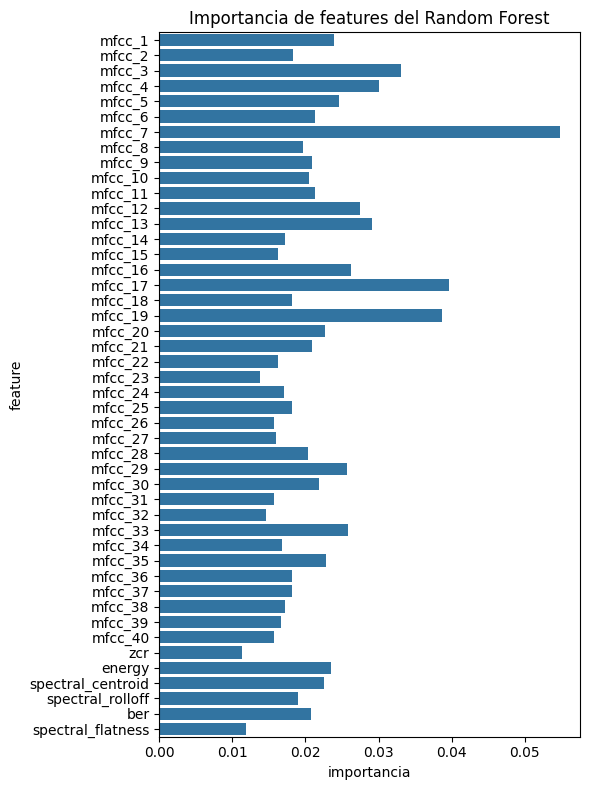

In [29]:
importances = feat_rf.feature_importances_
columns = ['mfcc_' + str(i) for i in range(1, 41)] + ['zcr', 'energy', 'spectral_centroid', 'spectral_rolloff', 'ber', 'spectral_flatness']

importance_df = pd.DataFrame({
    'feature': columns,
    'importancia': importances
})
plt.figure(figsize=(6, 8))
sns.barplot(data=importance_df, x='importancia', y='feature')
plt.title('Importancia de features del Random Forest')
plt.tight_layout();

In [30]:
y_pred = feat_rf.predict(X_test)
y_pred_proba = feat_rf.predict_proba(X_test)[:, 1]

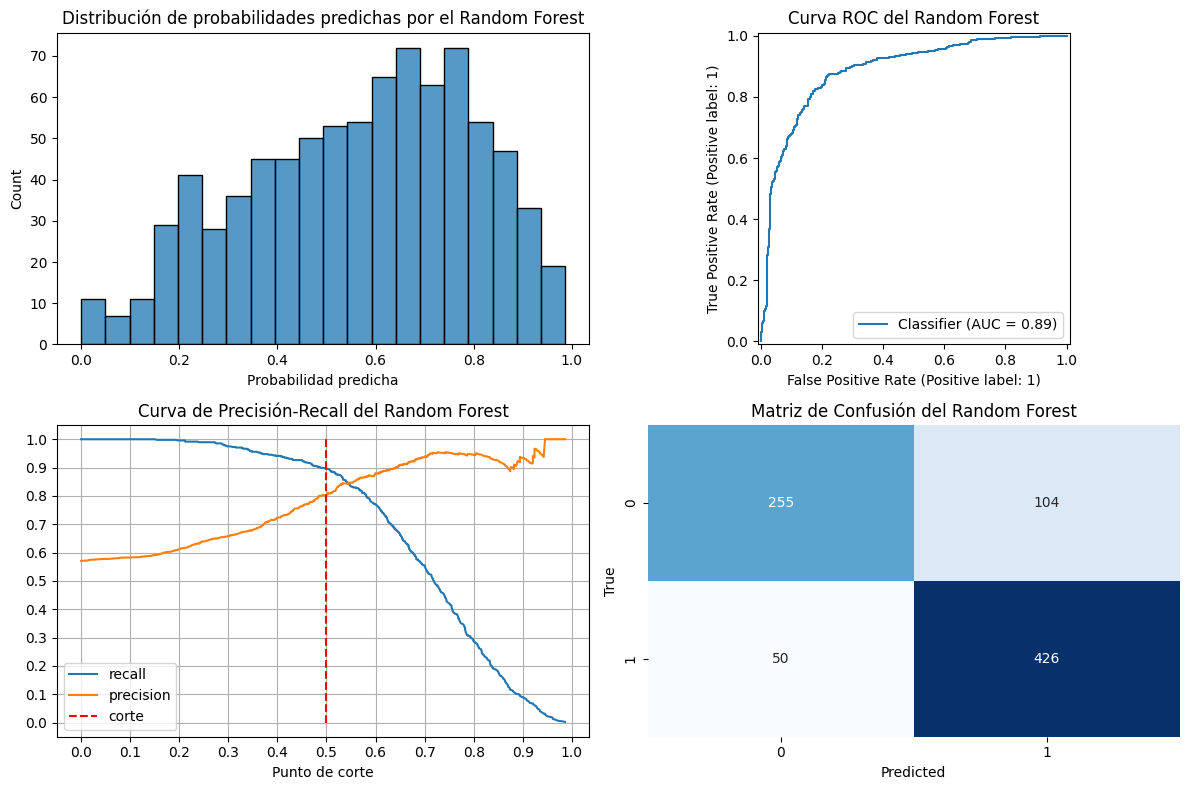

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(y_pred_proba, bins=20, ax=axes[0,0])
axes[0,0].set_title('Distribución de probabilidades predichas por el Random Forest')
axes[0,0].set_xlabel('Probabilidad predicha')

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0,1])
axes[0,1].set_title('Curva ROC del Random Forest')

show_precision_recall_curve(y_test, y_pred_proba, ax=axes[1,0])
axes[1,0].set_title('Curva de Precisión-Recall del Random Forest')

show_confusion_matrix(y_test, y_pred, ax=axes[1,1])
axes[1,1].set_title('Matriz de Confusión del Random Forest')

plt.tight_layout()

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.71      0.77       359
           1       0.80      0.89      0.85       476

    accuracy                           0.82       835
   macro avg       0.82      0.80      0.81       835
weighted avg       0.82      0.82      0.81       835



## CNN

### Imagenes de Mel Espectrogramas

In [33]:
test_dir = f'./data_procesada/{dataset}/imgs/test'

X_test, y_test = load_image_dataset(test_dir, target_size=(372, 128)) # ojo con el tamaño, cambia según el dataset

In [34]:
cnn_img = keras.models.load_model(f'./neural_network/modelos/{dataset}/imgs.keras')

In [35]:
y_pred_proba = cnn_img.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int)

27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 498ms/step


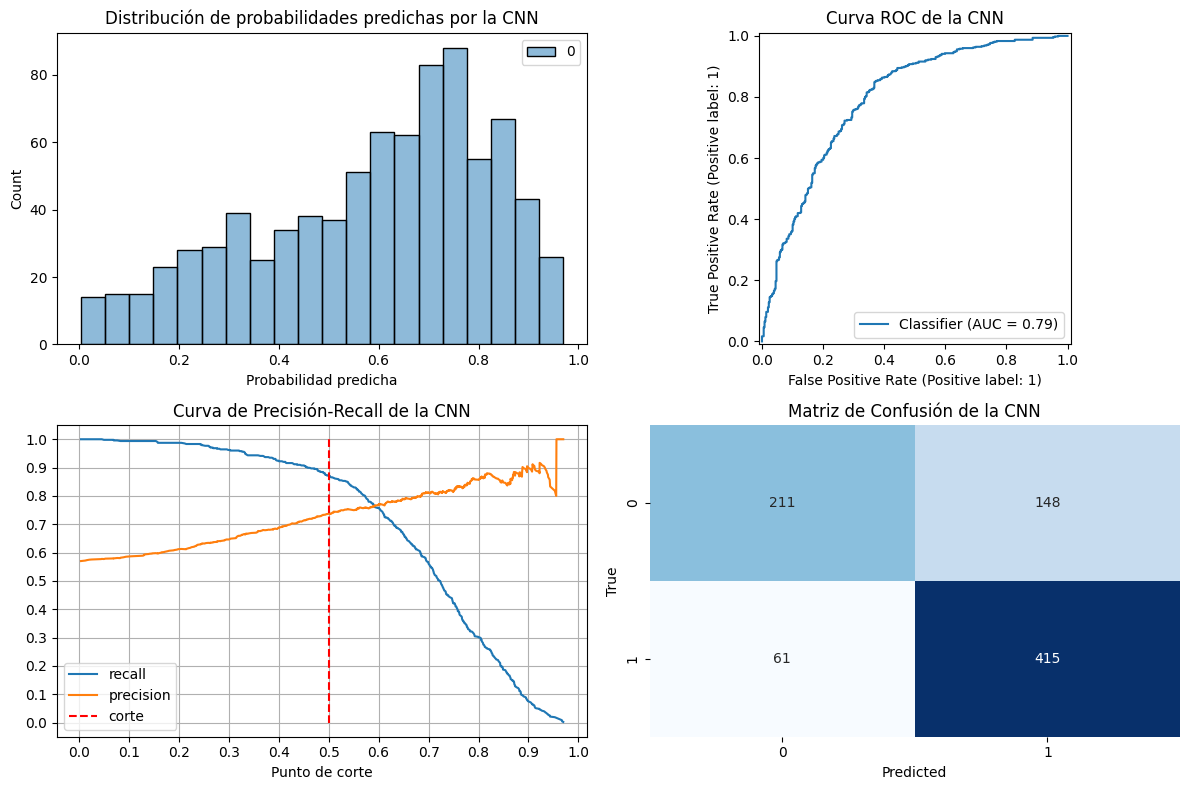

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(y_pred_proba, bins=20, ax=axes[0,0])
axes[0,0].set_title('Distribución de probabilidades predichas por la CNN')
axes[0,0].set_xlabel('Probabilidad predicha')

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0,1])
axes[0,1].set_title('Curva ROC de la CNN')

show_precision_recall_curve(y_test, y_pred_proba, ax=axes[1,0])
axes[1,0].set_title('Curva de Precisión-Recall de la CNN')

show_confusion_matrix(y_test, y_pred, ax=axes[1,1])
axes[1,1].set_title('Matriz de Confusión de la CNN')
plt.tight_layout()

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.59      0.67       359
           1       0.74      0.87      0.80       476

    accuracy                           0.75       835
   macro avg       0.76      0.73      0.73       835
weighted avg       0.75      0.75      0.74       835



### Mel Espectrograma (Matriz)

In [38]:
test_data = np.load(f'./data_procesada/{dataset}/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [39]:
X_test = X_test.reshape(-1, 128, 372, 1) # ojo con el tamaño, cambia según el dataset
X_test = np.repeat(X_test, 3, axis=-1)

In [40]:
cnn_melspec = keras.models.load_model(f'./neural_network/modelos/{dataset}/melspec.keras')

In [41]:
y_pred_proba = cnn_melspec.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int)

27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 499ms/step


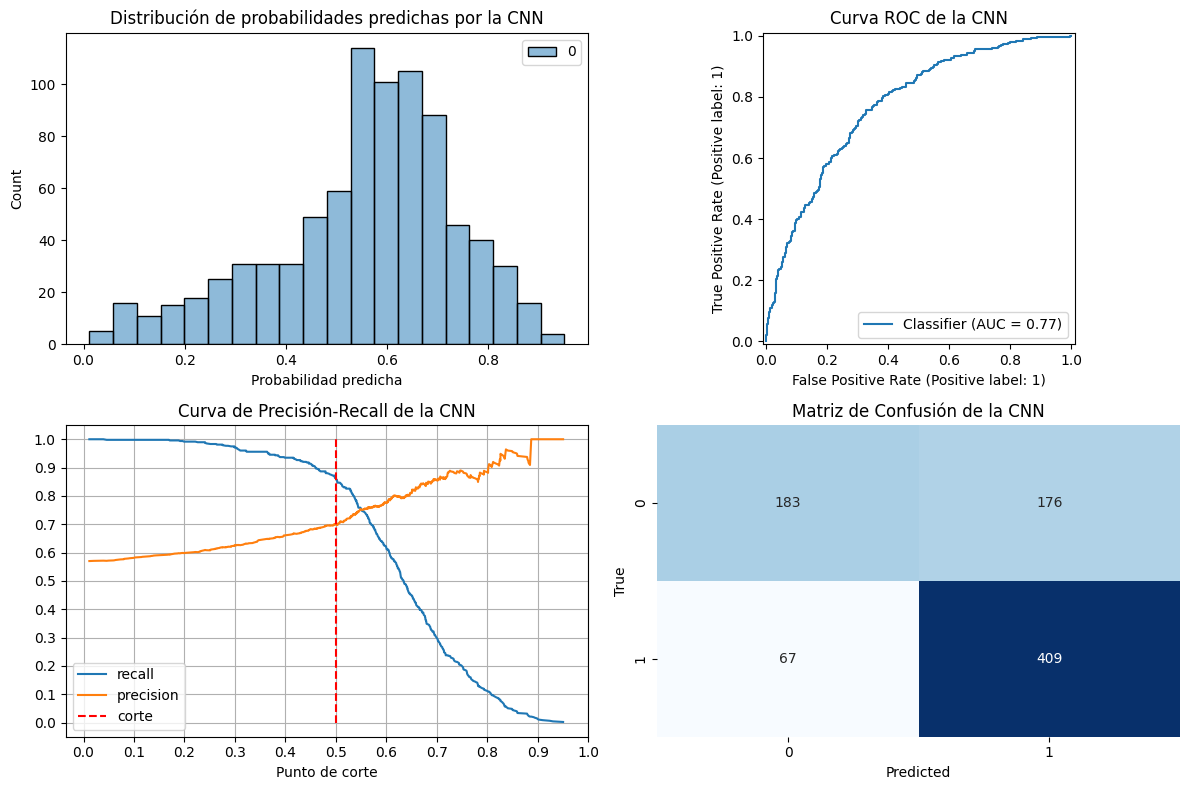

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(y_pred_proba, bins=20, ax=axes[0,0])
axes[0,0].set_title('Distribución de probabilidades predichas por la CNN')
axes[0,0].set_xlabel('Probabilidad predicha')

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0,1])
axes[0,1].set_title('Curva ROC de la CNN')

show_precision_recall_curve(y_test, y_pred_proba, ax=axes[1,0])
axes[1,0].set_title('Curva de Precisión-Recall de la CNN')

show_confusion_matrix(y_test, y_pred, ax=axes[1,1])
axes[1,1].set_title('Matriz de Confusión de la CNN')
plt.tight_layout()

In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.51      0.60       359
           1       0.70      0.86      0.77       476

    accuracy                           0.71       835
   macro avg       0.72      0.68      0.69       835
weighted avg       0.71      0.71      0.70       835

